In [7]:
from sklearn.datasets import load_iris
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-02-23 10:22:29.270207: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 10:22:29.270597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 10:22:29.840906: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 10:22:31.818622: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
help(load_iris)

Help on function load_iris in module sklearn.datasets._base:

load_iris(*, return_X_y=False, as_frame=False)
    Load and return the iris dataset (classification).

    The iris dataset is a classic and very easy multi-class classification
    dataset.

    =================   ==============
    Classes                          3
    Samples per class               50
    Samples total                  150
    Dimensionality                   4
    Features            real, positive
    =================   ==============

    Read more in the :ref:`User Guide <iris_dataset>`.

    .. versionchanged:: 0.20
        Fixed two wrong data points according to Fisher's paper.
        The new version is the same as in R, but not as in the UCI
        Machine Learning Repository.

    Parameters
    ----------
    return_X_y : bool, default=False
        If True, returns ``(data, target)`` instead of a Bunch object. See
        below for more information about the `data` and `target` object.

 

In [3]:
data = load_iris()

In [47]:
model = Sequential()
model.add(Dense(10,input_shape=(4,), activation='relu'))
model.add(Dense(5, activation='relu'))
model.add(Dense(3, activation='softmax'))

/workspaces/python/env/sklearn-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
X = data['data']
Y = data['target']

In [12]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
from tensorflow.keras.utils import to_categorical

In [15]:
y_c = to_categorical(Y)

In [48]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
fit_data = Out.get(36)

In [23]:
import matplotlib.pyplot as plt
plt.plot(fit_data.history['loss'])
plt.plot(fit_data.history['accuracy'])

AttributeError: 'NoneType' object has no attribute 'history'

In [24]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y_c, test_size=0.2)

In [38]:
y_test

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [49]:
hist = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=500)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3417 - loss: 1.8516 - val_accuracy: 0.3000 - val_loss: 1.9019
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3417 - loss: 1.7651 - val_accuracy: 0.3000 - val_loss: 1.8053
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3417 - loss: 1.6732 - val_accuracy: 0.3000 - val_loss: 1.7147
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3417 - loss: 1.5926 - val_accuracy: 0.3000 - val_loss: 1.6283
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3417 - loss: 1.5128 - val_accuracy: 0.3000 - val_loss: 1.5474
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3417 - loss: 1.4394 - val_accuracy: 0.3000 - val_loss: 1.4726
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3417 - loss: 1.3759 - val_accuracy: 0.3000 - val_loss: 1.4033
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3417 - loss: 1.3111 - val_accuracy: 0.3000 - val_loss:

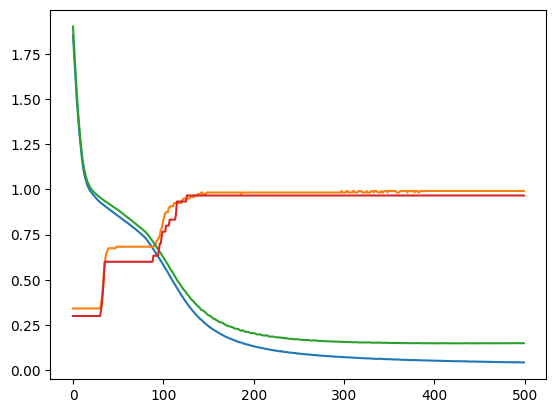

In [50]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_loss'])
plt.plot(hist.history['val_accuracy'])

In [40]:
Y_predicted = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


In [42]:
Y_predicted

array([[8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [1.2751161e-04, 9.2479336e-01, 7.5079128e-02],
       [1.1719076e-04, 5.4324526e-01, 4.5663756e-01],
       [6.0652760e-06, 3.1607041e-01, 6.8392354e-01],
       [8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [4.4456341e-05, 1.2469880e-01, 8.7525678e-01],
       [9.1232808e-04, 9.6223813e-01, 3.6849596e-02],
       [1.0964648e-04, 3.4447479e-01, 6.5541559e-01],
       [8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [2.1970465e-05, 1.1548312e-01, 8.8449502e-01],
       [6.0993398e-04, 9.6600235e-01, 3.3387709e-02],
       [7.2080169e-05, 2.2616838e-01, 7.7375960e-01],
       [4.8831257e-04, 8.1146038e-01, 1.8805134e-01],
       [8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [3.8407266e-04, 9.7119260e-01, 2.8423321e-02],
       [2.6870630e-04, 8.6541438e-01, 1.3431689e-01],
       [8.5420203e-01, 8.8100165e-02, 5.7697799e-02],
       [1.8964025e-06, 1.842

In [43]:
y_test

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [44]:
from sklearn.metrics import classification_report, confusion_matrix

In [45]:
cm = confusion_matrix(y_test.argmax(axis=1), Y_predicted.argmax(axis=1))
cm

array([[ 9,  0,  0],
       [ 0, 11,  1],
       [ 0,  1,  8]])

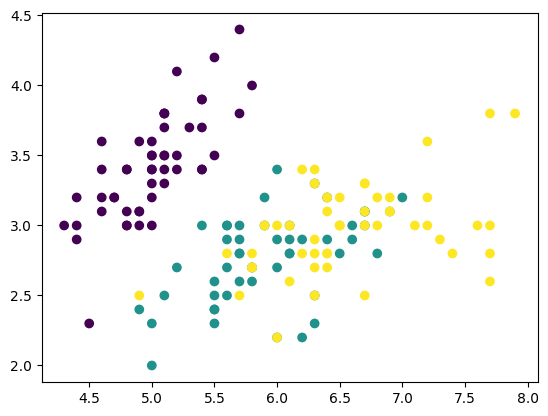

In [46]:
plt.scatter(X[:,0], X[:,1], c=Y)